# Notebook 13 - Uncertainty Quantification (Conformal)\n
\n
This notebook adds conformal prediction intervals on top of the selected geothermal regression baseline and reports RMSE, R2, PICP, MPIW, and ACE across random split, GroupKFold, and spatial holdout protocols.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    from xgboost import XGBRegressor
except Exception:
    XGBRegressor = None

NOTEBOOK_ROOT = Path.cwd() if Path.cwd().name == "13_uncertainty_conformal_no_scripts" else Path(r"c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/github_org_bootstrap/phd-geothermal-ml/manual_bootstrap/step_by_step_notebooks/13_uncertainty_conformal_no_scripts")
PROJECT_ROOT = NOTEBOOK_ROOT.parents[2]
PHD_OS_ROOT = PROJECT_ROOT.parents[1]
OUTPUT_ROOT = NOTEBOOK_ROOT / "outputs" / "summary"
TABLE_ROOT = OUTPUT_ROOT / "tables"
REPORT_ROOT = OUTPUT_ROOT / "reports"
TABLE_ROOT.mkdir(parents=True, exist_ok=True)
REPORT_ROOT.mkdir(parents=True, exist_ok=True)

data_candidates = [
    PROJECT_ROOT / "datasets" / "geothermal_canonical_v2_0_0.csv",
    PHD_OS_ROOT / "03_data_processed" / "geothermal_canonical_v2_0_0.csv",
    PHD_OS_ROOT / "02_data_raw" / "geothermal_canonical_v2_0_0.csv",
    PHD_OS_ROOT / "incoming_from_legacy" / "geothermal_canonical_v2_0_0.csv",
]
data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find geothermal_canonical_v2_0_0.csv in expected locations.")

df = pd.read_csv(data_path)
TARGET = "Temperature(C)"
GROUP_COL = "State"
drop_cols = [c for c in [TARGET] if c in df.columns]
X_raw = df.drop(columns=drop_cols).copy()
y_all = df[TARGET].copy()
groups_all = df[GROUP_COL].astype(str).copy() if GROUP_COL in df.columns else pd.Series(["ALL"] * len(df))

numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_raw.columns if c not in numeric_cols]

num_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
cat_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocess = ColumnTransformer([("num", num_pipe, numeric_cols), ("cat", cat_pipe, categorical_cols)], remainder="drop")

if XGBRegressor is None:
    xgb = ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1)
else:
    xgb = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.9, colsample_bytree=0.9, objective="reg:squarederror", random_state=42, n_jobs=4)

base_model = VotingRegressor([
    ("gbm", GradientBoostingRegressor(random_state=42, n_estimators=350, learning_rate=0.05, max_depth=3)),
    ("xgb", xgb),
    ("et", ExtraTreesRegressor(n_estimators=400, random_state=42, n_jobs=-1))
])

model = Pipeline([("prep", preprocess), ("reg", base_model)])


def conformal_interval(y_cal, y_cal_pred, y_test_pred, alpha=0.10):
    resid = np.abs(np.asarray(y_cal) - np.asarray(y_cal_pred))
    n = resid.shape[0]
    q_idx = int(np.ceil((n + 1) * (1 - alpha))) - 1
    q_idx = min(max(q_idx, 0), n - 1)
    q = np.sort(resid)[q_idx]
    lower = np.asarray(y_test_pred) - q
    upper = np.asarray(y_test_pred) + q
    return lower, upper, q


def metrics_with_uncertainty(y_true, y_pred, lower, upper, alpha=0.10):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))
    inside = ((y_true >= lower) & (y_true <= upper)).astype(float)
    picp = float(np.mean(inside))
    mpiw = float(np.mean(upper - lower))
    nominal = float(1 - alpha)
    ace = float(abs(picp - nominal))
    return rmse, r2, picp, mpiw, ace, nominal


rows = []
alpha = 0.10

# Random split protocol
for seed in range(10):
    idx = np.arange(len(X_raw))
    tr_idx, te_idx = train_test_split(idx, test_size=0.2, random_state=seed)
    tr_sub, cal_sub = train_test_split(tr_idx, test_size=0.2, random_state=seed)

    X_tr = X_raw.iloc[tr_sub]
    y_tr = y_all.iloc[tr_sub]
    X_cal = X_raw.iloc[cal_sub]
    y_cal = y_all.iloc[cal_sub]
    X_te = X_raw.iloc[te_idx]
    y_te = y_all.iloc[te_idx]

    model.fit(X_tr, y_tr)
    cal_pred = model.predict(X_cal)
    te_pred = model.predict(X_te)
    lower, upper, _ = conformal_interval(y_cal, cal_pred, te_pred, alpha=alpha)
    rmse, r2, picp, mpiw, ace, nominal = metrics_with_uncertainty(y_te.values, te_pred, lower, upper, alpha=alpha)

    rows.append({"protocol": "random_split", "split_id": seed, "rmse": rmse, "r2": r2, "picp": picp, "mpiw": mpiw, "ace": ace, "nominal": nominal})

# GroupKFold protocol
gkf = GroupKFold(n_splits=5)
for fold_idx, (tr_idx, te_idx) in enumerate(gkf.split(X_raw, y_all, groups=groups_all), start=1):
    tr_sub, cal_sub = train_test_split(tr_idx, test_size=0.2, random_state=100 + fold_idx)

    X_tr = X_raw.iloc[tr_sub]
    y_tr = y_all.iloc[tr_sub]
    X_cal = X_raw.iloc[cal_sub]
    y_cal = y_all.iloc[cal_sub]
    X_te = X_raw.iloc[te_idx]
    y_te = y_all.iloc[te_idx]

    model.fit(X_tr, y_tr)
    cal_pred = model.predict(X_cal)
    te_pred = model.predict(X_te)
    lower, upper, _ = conformal_interval(y_cal, cal_pred, te_pred, alpha=alpha)
    rmse, r2, picp, mpiw, ace, nominal = metrics_with_uncertainty(y_te.values, te_pred, lower, upper, alpha=alpha)

    rows.append({"protocol": "groupkfold", "split_id": fold_idx, "rmse": rmse, "r2": r2, "picp": picp, "mpiw": mpiw, "ace": ace, "nominal": nominal})

# Spatial holdout protocol
group_counts = groups_all.value_counts()
eligible_groups = group_counts[group_counts >= 30].index.tolist()
for g in eligible_groups:
    te_mask = groups_all == g
    tr_idx = np.where(~te_mask.values)[0]
    te_idx = np.where(te_mask.values)[0]
    if len(te_idx) < 30 or len(tr_idx) < 100:
        continue

    tr_sub, cal_sub = train_test_split(tr_idx, test_size=0.2, random_state=7)
    X_tr = X_raw.iloc[tr_sub]
    y_tr = y_all.iloc[tr_sub]
    X_cal = X_raw.iloc[cal_sub]
    y_cal = y_all.iloc[cal_sub]
    X_te = X_raw.iloc[te_idx]
    y_te = y_all.iloc[te_idx]

    model.fit(X_tr, y_tr)
    cal_pred = model.predict(X_cal)
    te_pred = model.predict(X_te)
    lower, upper, _ = conformal_interval(y_cal, cal_pred, te_pred, alpha=alpha)
    rmse, r2, picp, mpiw, ace, nominal = metrics_with_uncertainty(y_te.values, te_pred, lower, upper, alpha=alpha)

    rows.append({"protocol": "spatial_holdout", "split_id": str(g), "rmse": rmse, "r2": r2, "picp": picp, "mpiw": mpiw, "ace": ace, "nominal": nominal})

runs_df = pd.DataFrame(rows)
summary = runs_df.groupby("protocol", as_index=False)[["rmse", "r2", "picp", "mpiw", "ace", "nominal"]].mean()
summary = summary.sort_values("protocol")

runs_df.to_csv(TABLE_ROOT / "all_runs_uncertainty_conformal.csv", index=False)
summary.to_csv(TABLE_ROOT / "protocol_summary_uncertainty_conformal.csv", index=False)

lines = [
    "# Notebook 13 Uncertainty Summary",
    "",
    f"Rows in all runs: {len(runs_df)}",
    "",
]
for _, r in summary.iterrows():
    lines.append(f"- {r['protocol']}: RMSE={r['rmse']:.4f}, R2={r['r2']:.4f}, PICP={r['picp']:.4f}, MPIW={r['mpiw']:.4f}, ACE={r['ace']:.4f}, nominal={r['nominal']:.2f}")
(REPORT_ROOT / "uncertainty_interpretation_notes.md").write_text("\n".join(lines), encoding="utf-8")

print("Saved:", TABLE_ROOT / "all_runs_uncertainty_conformal.csv")
print("Saved:", TABLE_ROOT / "protocol_summary_uncertainty_conformal.csv")
print("Saved:", REPORT_ROOT / "uncertainty_interpretation_notes.md")
summary

Saved: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\13_uncertainty_conformal_no_scripts\outputs\summary\tables\all_runs_uncertainty_conformal.csv
Saved: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\13_uncertainty_conformal_no_scripts\outputs\summary\tables\protocol_summary_uncertainty_conformal.csv
Saved: c:\Users\obalo\Downloads\PhDOneDrive\PhD_Research_Operating_System\github_org_bootstrap\phd-geothermal-ml\manual_bootstrap\step_by_step_notebooks\13_uncertainty_conformal_no_scripts\outputs\summary\reports\uncertainty_interpretation_notes.md


,protocol,rmse,r2,picp,mpiw,ace,nominal
0,groupkfold,33.098560,-10.293057,0.708536,49.215122,0.223131,0.9
1,random_split,19.422582,0.659114,0.892551,50.839659,0.019032,0.9
2,spatial_holdout,29.194097,-25.503958,0.769570,47.767348,0.146402,0.9


=== X1.2 Conformal Prediction Metrics (Paper 6) ===
 alpha     PICP      ACE       MPIW     RMSE       R2
  0.02 0.969832 0.014994 107.250995 19.61429 0.645879
  0.05 0.939665 0.020428  69.722400 19.61429 0.645879
  0.10 0.888268 0.020968  48.288099 19.61429 0.645879
  0.15 0.841341 0.015847  37.989876 19.61429 0.645879
  0.20 0.788827 0.016983  30.823642 19.61429 0.645879


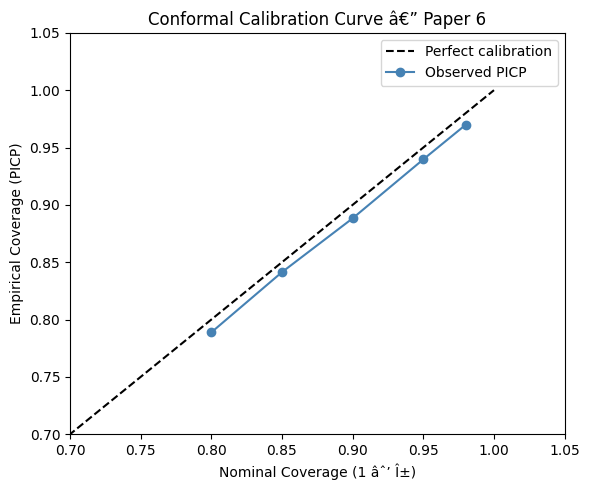


Per-state coverage (alpha=0.10, nominal=0.90):
     state   n     PICP      MPIW
     Idaho  10 0.500000 43.757009
California 110 0.881818 43.757009
    Nevada 364 0.881868 43.757009
    Oregon  15 1.000000 43.757009
   Wyoming  22 1.000000 43.757009


In [2]:
# X1.2 â€” PICP, ACE, MPIW conformal prediction metrics + calibration curve
# Required for Paper 6. Adds reviewer-standard interval quality metrics.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor, ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    _xgb = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=4)
except ImportError:
    _xgb = ExtraTreesRegressor(n_estimators=300, random_state=42)

_data_path = Path(r'c:/Users/obalo/Downloads/PhDOneDrive/PhD_Research_Operating_System/03_data_processed/geothermal_canonical_v2_0_0.csv')
_df = pd.read_csv(_data_path)
_TARGET = 'Temperature(C)'; _GROUP = 'State'
_X = _df.drop(columns=[_TARGET]); _y = _df[_TARGET]; _g = _df[_GROUP]

_num_cols = _X.select_dtypes(include=[np.number]).columns.tolist()
_cat_cols = [c for c in _X.columns if c not in _num_cols]
_prep = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), _num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore'))]), _cat_cols),
])
_base = VotingRegressor([
    ('gbm', GradientBoostingRegressor(n_estimators=350, learning_rate=0.05, max_depth=3, random_state=42)),
    ('xgb', _xgb),
    ('et', ExtraTreesRegressor(n_estimators=400, random_state=42, n_jobs=-1)),
])
_model = Pipeline([('prep', _prep), ('reg', _base)])


def _conformal_interval(y_cal, y_cal_pred, y_test_pred, alpha=0.10):
    resid = np.abs(np.asarray(y_cal) - np.asarray(y_cal_pred))
    n = len(resid)
    q_idx = min(int(np.ceil((n + 1) * (1 - alpha))) - 1, n - 1)
    q = np.sort(resid)[q_idx]
    return np.asarray(y_test_pred) - q, np.asarray(y_test_pred) + q


def _conformal_metrics(y_true, y_pred, lower, upper, alpha=0.10):
    picp = float(np.mean((y_true >= lower) & (y_true <= upper)))
    mpiw = float(np.mean(upper - lower))
    ace = float(abs(picp - (1 - alpha)))
    return {'PICP': picp, 'ACE': ace, 'MPIW': mpiw, 'nominal': 1 - alpha,
            'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
            'R2': float(r2_score(y_true, y_pred))}


# Calibration curve across alpha levels
_alphas = [0.02, 0.05, 0.10, 0.15, 0.20]
_all_rows = []

for _seed in range(5):
    _idx = np.arange(len(_X))
    _tr, _te = train_test_split(_idx, test_size=0.2, random_state=_seed)
    _tr_sub, _cal = train_test_split(_tr, test_size=0.2, random_state=_seed + 100)
    _model.fit(_X.iloc[_tr_sub], _y.iloc[_tr_sub])
    _cal_pred = _model.predict(_X.iloc[_cal])
    _te_pred = _model.predict(_X.iloc[_te])
    for _a in _alphas:
        _lo, _hi = _conformal_interval(_y.iloc[_cal], _cal_pred, _te_pred, alpha=_a)
        _m = _conformal_metrics(_y.iloc[_te].values, _te_pred, _lo, _hi, alpha=_a)
        _m.update({'seed': _seed, 'alpha': _a})
        _all_rows.append(_m)

_conf_df = pd.DataFrame(_all_rows)
_summary = _conf_df.groupby('alpha')[['PICP', 'ACE', 'MPIW', 'RMSE', 'R2']].mean().reset_index()
print("=== X1.2 Conformal Prediction Metrics (Paper 6) ===")
print(_summary.to_string(index=False))

# Calibration curve
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(1 - _summary['alpha'], _summary['PICP'], 'o-', label='Observed PICP', color='steelblue')
ax.set_xlabel('Nominal Coverage (1 âˆ’ Î±)'); ax.set_ylabel('Empirical Coverage (PICP)')
ax.set_title('Conformal Calibration Curve â€” Paper 6')
ax.legend(); ax.set_xlim(0.7, 1.05); ax.set_ylim(0.7, 1.05)
plt.tight_layout(); plt.savefig('conformal_calibration_curve.png', dpi=600); plt.show()

# Per-state coverage at alpha=0.10
_tr90, _te90 = train_test_split(np.arange(len(_X)), test_size=0.2, random_state=0)
_tr90_sub, _cal90 = train_test_split(_tr90, test_size=0.2, random_state=100)
_model.fit(_X.iloc[_tr90_sub], _y.iloc[_tr90_sub])
_cal_pred90 = _model.predict(_X.iloc[_cal90])
_te_pred90 = _model.predict(_X.iloc[_te90])
_lo90, _hi90 = _conformal_interval(_y.iloc[_cal90], _cal_pred90, _te_pred90, alpha=0.10)
_te_g = _g.iloc[_te90].values
_state_rows = []
for _state in np.unique(_te_g):
    _mask = _te_g == _state
    if _mask.sum() < 10:
        continue
    _picp = float(np.mean((_y.iloc[_te90].values[_mask] >= _lo90[_mask]) &
                           (_y.iloc[_te90].values[_mask] <= _hi90[_mask])))
    _state_rows.append({'state': _state, 'n': int(_mask.sum()), 'PICP': _picp,
                        'MPIW': float(np.mean(_hi90[_mask] - _lo90[_mask]))})
_state_df = pd.DataFrame(_state_rows).sort_values('PICP')
print("\nPer-state coverage (alpha=0.10, nominal=0.90):")
print(_state_df.to_string(index=False))

In [3]:
# N8.5 â€” Environment watermark for reproducibility
try:
    import watermark
    %load_ext watermark
    %watermark -v -p numpy,pandas,scikit-learn,scipy,matplotlib,xgboost
except ImportError:
    import sys, numpy, pandas, sklearn, scipy, matplotlib
    print(f"Python {sys.version}")
    print(f"numpy={numpy.__version__}, pandas={pandas.__version__}")
    print(f"scikit-learn={sklearn.__version__}, scipy={scipy.__version__}")
    print(f"matplotlib={matplotlib.__version__}")
    try:
        import xgboost; print(f"xgboost={xgboost.__version__}")
    except ImportError:
        pass

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.11.0

numpy       : 2.4.2
pandas      : 2.2.2
scikit-learn: 1.8.0
scipy       : 1.17.1
matplotlib  : 3.10.8
xgboost     : 3.2.0

